# E-commerce Sales Analytics

End-to-end data analysis project using PostgreSQL, Python, Pandas and Power BI.

## Python Analysis
This notebook covers:
- data quality checks
- sales and profitability analysis
- product and customer analysis
- customer segmentation
- Pareto analysis
- RFM analysis
- repeat purchase behavior
- discount analysis
- business recommendations

In [100]:
import os

colab_path = "/content/sales_details.csv"
local_path = "../data/sales_details.csv"

if os.path.exists(colab_path):
  file_path = colab_path
else:
  file_path = local_path

df = pd.read_csv(file_path)
df.head()


,order_id,order_date,order_status,payment_method,shipping_city,customer_id,first_name,last_name,order_item_id,product_id,product_name,category_name,quantity,unit_price,cost_price,discount_percent,gross_amount,net_amount,profit
0,1,2025-01-25,Pending,Bank Transfer,Konin,1,Anna,Kowalska,1,20,Xbox Series X,Gaming,1,2499.0,2020.0,10.0,2499.0,2249.1,229.1
1,1,2025-01-25,Pending,Bank Transfer,Konin,1,Anna,Kowalska,2,21,Nintendo Switch OLED,Gaming,2,1599.0,1240.0,0.0,3198.0,3198.0,718.0
2,2,2025-01-31,Completed,Cash on Delivery,Olsztyn,2,Piotr,Nowak,3,15,USB-C Hub 8-in-1,Accessories,3,249.0,145.0,0.0,747.0,747.0,312.0
3,2,2025-01-31,Completed,Cash on Delivery,Olsztyn,2,Piotr,Nowak,4,20,Xbox Series X,Gaming,2,2499.0,2020.0,0.0,4998.0,4998.0,958.0
4,2,2025-01-31,Completed,Cash on Delivery,Olsztyn,2,Piotr,Nowak,5,21,Nintendo Switch OLED,Gaming,3,1599.0,1240.0,0.0,4797.0,4797.0,1077.0


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("/content/sales_details.csv")
df.head()

,order_id,order_date,order_status,payment_method,shipping_city,customer_id,first_name,last_name,order_item_id,product_id,product_name,category_name,quantity,unit_price,cost_price,discount_percent,gross_amount,net_amount,profit
0,1,2025-01-25,Pending,Bank Transfer,Konin,1,Anna,Kowalska,1,20,Xbox Series X,Gaming,1,2499.0,2020.0,10.0,2499.0,2249.1,229.1
1,1,2025-01-25,Pending,Bank Transfer,Konin,1,Anna,Kowalska,2,21,Nintendo Switch OLED,Gaming,2,1599.0,1240.0,0.0,3198.0,3198.0,718.0
2,2,2025-01-31,Completed,Cash on Delivery,Olsztyn,2,Piotr,Nowak,3,15,USB-C Hub 8-in-1,Accessories,3,249.0,145.0,0.0,747.0,747.0,312.0
3,2,2025-01-31,Completed,Cash on Delivery,Olsztyn,2,Piotr,Nowak,4,20,Xbox Series X,Gaming,2,2499.0,2020.0,0.0,4998.0,4998.0,958.0
4,2,2025-01-31,Completed,Cash on Delivery,Olsztyn,2,Piotr,Nowak,5,21,Nintendo Switch OLED,Gaming,3,1599.0,1240.0,0.0,4797.0,4797.0,1077.0


In [6]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7350 entries, 0 to 7349
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          7350 non-null   int64  
 1   order_date        7350 non-null   object 
 2   order_status      7350 non-null   object 
 3   payment_method    7350 non-null   object 
 4   shipping_city     7350 non-null   object 
 5   customer_id       7350 non-null   int64  
 6   first_name        7350 non-null   object 
 7   last_name         7350 non-null   object 
 8   order_item_id     7350 non-null   int64  
 9   product_id        7350 non-null   int64  
 10  product_name      7350 non-null   object 
 11  category_name     7350 non-null   object 
 12  quantity          7350 non-null   int64  
 13  unit_price        7350 non-null   float64
 14  cost_price        7350 non-null   float64
 15  discount_percent  7350 non-null   float64
 16  gross_amount      7350 non-null   float64


In [7]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["order_date"].dtype

dtype('<M8[ns]')

In [8]:
df.isnull().sum()

,0
order_id,0
order_date,0
order_status,0
payment_method,0
shipping_city,0
customer_id,0
first_name,0
last_name,0
order_item_id,0
product_id,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.groupby("order_status")["order_id"].nunique()

,order_id
order_status,
Cancelled,492
Completed,1722
Pending,246


In [11]:
completed = df[df["order_status"] == "Completed"].copy()
print(completed.shape)
print(completed["order_id"].nunique())

(5144, 19)
1722


In [12]:
total_revenue = completed["net_amount"].sum()
total_profit = completed["profit"].sum()
total_orders = completed["order_id"].nunique()

print("Total Revenue:", round(total_revenue, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders", total_orders)

Total Revenue: 23185918.5
Total Profit: 5082773.84
Total Orders 1722


In [13]:
average_order_value = total_revenue / total_orders
print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 13464.53


In [14]:
units_sold = completed["quantity"].sum()

print("Units Sold:", units_sold)

Units Sold: 10226


In [15]:
category_analysis = (
    completed.groupby("category_name").agg(revenue = ("net_amount", "sum"),
                                           profit=("profit", "sum"),
                                           units_sold=("quantity", "sum"))
    .reset_index()
)

category_analysis

,category_name,revenue,profit,units_sold
0,Accessories,2499944.85,581966.55,1272
1,Audio,2580157.10,552307.30,1281
2,Gaming,2878035.00,579536.72,1266
3,Laptops,3243095.55,663757.27,1223
4,Monitors,3335417.85,760635.29,1398
5,Smart Home,2763792.05,683571.73,1372
6,Smartphones,3133924.25,662584.61,1239
7,Tablets,2751551.85,598414.37,1175


In [16]:
category_analysis = category_analysis.sort_values(
    "revenue",
    ascending=False
)

category_analysis

,category_name,revenue,profit,units_sold
4,Monitors,3335417.85,760635.29,1398
3,Laptops,3243095.55,663757.27,1223
6,Smartphones,3133924.25,662584.61,1239
2,Gaming,2878035.00,579536.72,1266
5,Smart Home,2763792.05,683571.73,1372
7,Tablets,2751551.85,598414.37,1175
1,Audio,2580157.10,552307.30,1281
0,Accessories,2499944.85,581966.55,1272


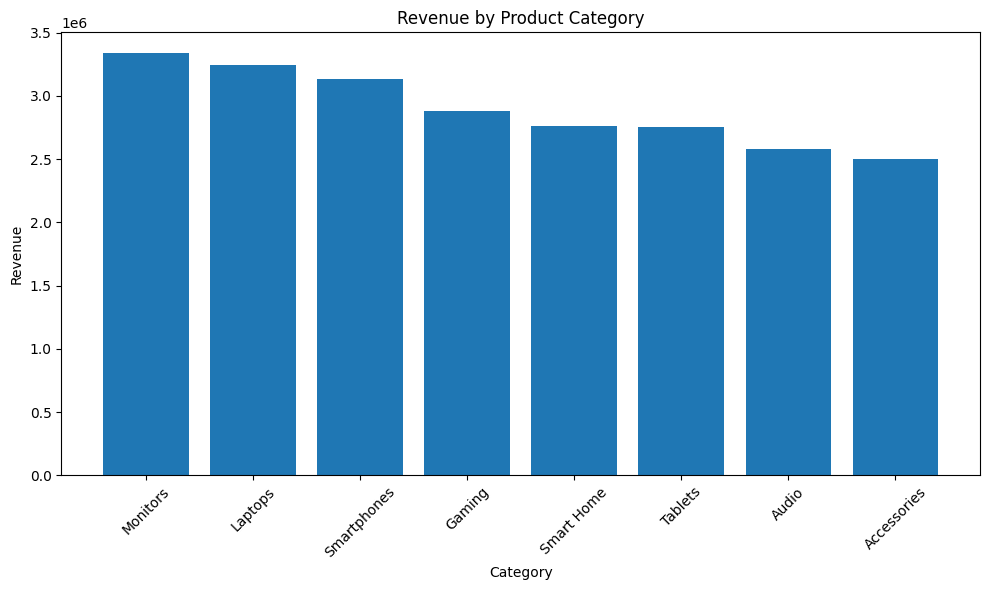

In [17]:
plt.figure(figsize=(10, 6))
plt.bar(
category_analysis["category_name"],
         category_analysis["revenue"]
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

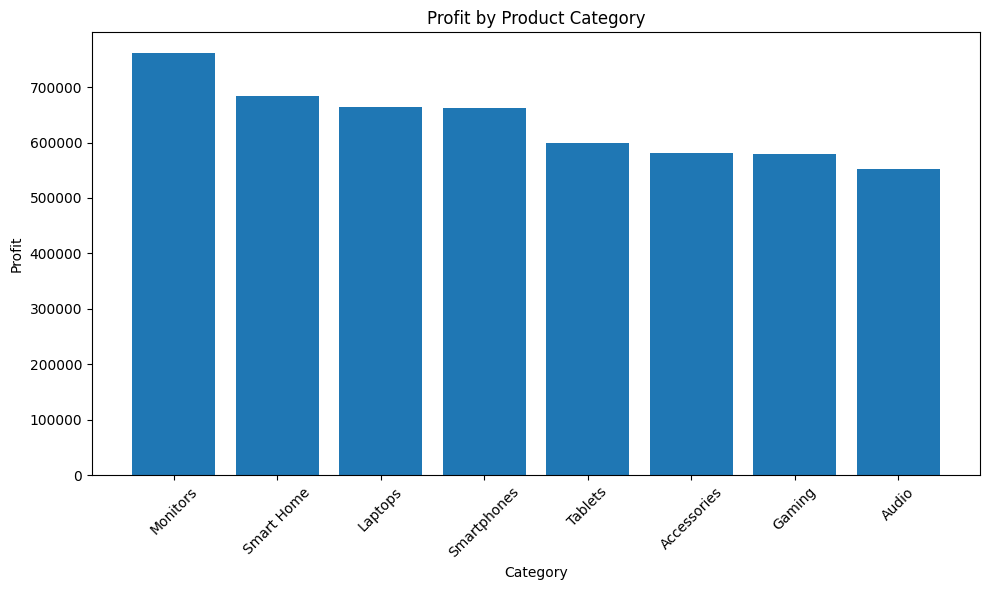

In [18]:
profit_by_category = category_analysis.sort_values(
    "profit",
    ascending=False
)

plt.figure(figsize=(10, 6))
plt.bar(
profit_by_category["category_name"],
         profit_by_category["profit"]
)

plt.title("Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [19]:
monthly_analysis = (
    completed
    .groupby(completed["order_date"].dt.to_period("M"))
    .agg(
        revenue=("net_amount", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

monthly_analysis

,order_date,revenue,profit,orders
0,2024-02,349952.40,74165.12,20
1,2024-03,585493.45,125208.75,58
2,2024-04,582094.55,129980.53,49
3,2024-05,549771.10,122800.32,44
4,2024-06,909031.60,196728.86,68
5,2024-07,876894.75,185581.59,67
6,2024-08,813896.65,181436.91,67
7,2024-09,1225276.95,264909.33,77
8,2024-10,1324058.20,299870.40,95
9,2024-11,806262.90,172811.48,60


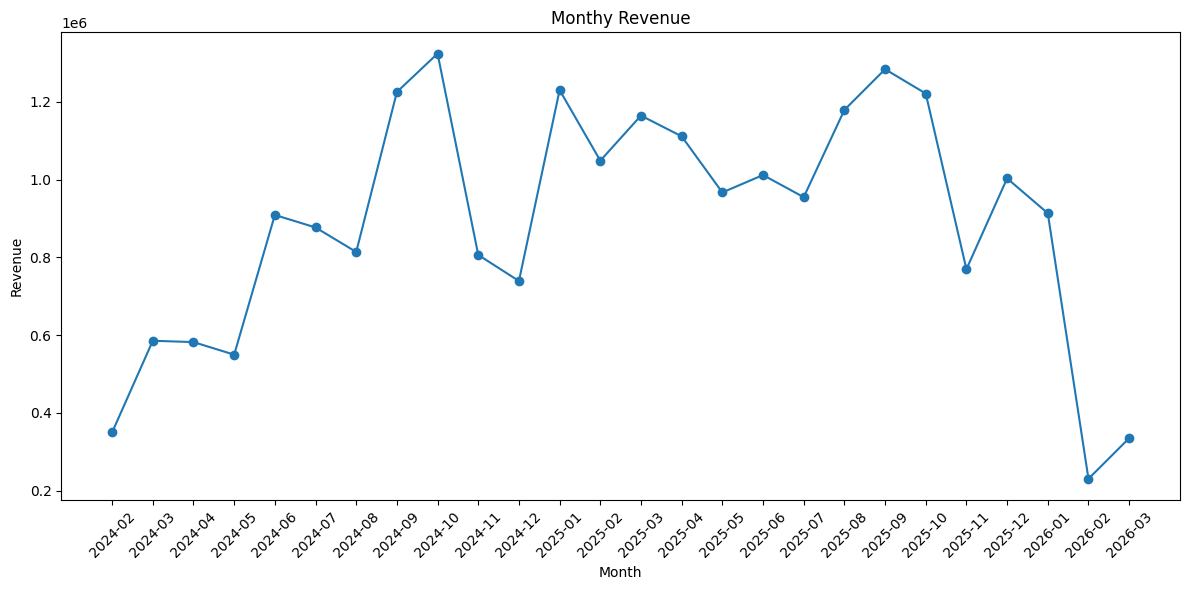

In [20]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_analysis["order_date"].astype(str),
    monthly_analysis["revenue"],
    marker="o"
)

plt.title("Monthy Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [21]:
monthly_analysis["revenue_growth_pct"] = (
    monthly_analysis["revenue"].pct_change() * 100
)

monthly_analysis[
    ["order_date", "revenue", "revenue_growth_pct"]
]

,order_date,revenue,revenue_growth_pct
0,2024-02,349952.40,NaN
1,2024-03,585493.45,67.306597
2,2024-04,582094.55,-0.580519
3,2024-05,549771.10,-5.552955
4,2024-06,909031.60,65.347287
5,2024-07,876894.75,-3.535284
6,2024-08,813896.65,-7.184226
7,2024-09,1225276.95,50.544538
8,2024-10,1324058.20,8.061953
9,2024-11,806262.90,-39.106687


In [22]:
monthly_analysis["aov"] = (
    monthly_analysis["revenue"] / monthly_analysis["orders"]
)

monthly_analysis[
    ["order_date", "revenue", "orders", "aov", "revenue_growth_pct"]
].round(2)


,order_date,revenue,orders,aov,revenue_growth_pct
0,2024-02,349952.40,20,17497.62,NaN
1,2024-03,585493.45,58,10094.71,67.31
2,2024-04,582094.55,49,11879.48,-0.58
3,2024-05,549771.10,44,12494.80,-5.55
4,2024-06,909031.60,68,13368.11,65.35
5,2024-07,876894.75,67,13087.98,-3.54
6,2024-08,813896.65,67,12147.71,-7.18
7,2024-09,1225276.95,77,15912.69,50.54
8,2024-10,1324058.20,95,13937.45,8.06
9,2024-11,806262.90,60,13437.72,-39.11


In [23]:
orders_corr = monthly_analysis["revenue"].corr(
    monthly_analysis["orders"]
)

aov_corr = monthly_analysis["revenue"].corr(
    monthly_analysis["aov"]
)

print("Revenue vs Orders:", round(orders_corr, 2))
print("Revenue vs AOV:", round(aov_corr, 2))

Revenue vs Orders: 0.96
Revenue vs AOV: -0.27


In [24]:
product_analysis = (
    completed
    .groupby(["product_id", "product_name"])
    .agg(
        revenue=("net_amount", "sum"),
        profit=("profit", "sum"),
        units_sold=("quantity", "sum")
    )
    .reset_index()
)

product_analysis[
    ["revenue", "profit"]
] = ( product_analysis[
    ["revenue", "profit"]].round(2)
)

product_analysis.head()

,product_id,product_name,revenue,profit,units_sold
0,1,Lenovo IdeaPad 5,206847.30,34597.30,65
1,2,ASUS TUF GAMING A15,284448.15,46368.15,64
2,3,MacBook Air M3,518830.65,63130.65,98
3,4,Samsung Galaxy S25,210147.45,34647.45,54
4,5,iPhone 16,327798.75,50898.75,78


In [25]:
top_products_revenue = (
    product_analysis
    .sort_values("revenue", ascending=False)
    .head(10)
)

top_products_revenue

,product_id,product_name,revenue,profit,units_sold
2,3,MacBook Air M3,518830.65,63130.65,98
131,484,Product_132,414170.40,87967.60,85
4,5,iPhone 16,327798.75,50898.75,78
1,2,ASUS TUF GAMING A15,284448.15,46368.15,64
122,475,Product_123,276269.40,83345.92,61
117,470,Product_118,268629.90,38809.54,62
118,471,Product_119,257571.60,34402.92,59
115,468,Product_116,255614.40,42163.20,60
127,480,Product_128,254373.60,63738.48,54
129,482,Product_130,252619.50,53764.50,54


In [26]:
top_products_profit = (
    product_analysis
    .sort_values("profit",
                 ascending=False)
    .head(10)
)

top_products_profit

,product_id,product_name,revenue,profit,units_sold
131,484,Product_132,414170.40,87967.60,85
122,475,Product_123,276269.40,83345.92,61
100,453,Product_101,251131.65,78927.09,68
119,472,Product_120,215877.00,71278.00,49
99,452,Product_100,220400.00,67260.00,62
82,435,Product_83,213408.30,66781.26,68
121,474,Product_122,200247.60,64226.88,44
127,480,Product_128,254373.60,63738.48,54
2,3,MacBook Air M3,518830.65,63130.65,98
125,478,Product_126,219766.30,60858.36,47


In [27]:
product_analysis["profit_margin_pct"] = (
    product_analysis["profit"]
    / product_analysis["revenue"]
    * 100
).round(2)

product_analysis.head()

,product_id,product_name,revenue,profit,units_sold,profit_margin_pct
0,1,Lenovo IdeaPad 5,206847.30,34597.30,65,16.73
1,2,ASUS TUF GAMING A15,284448.15,46368.15,64,16.30
2,3,MacBook Air M3,518830.65,63130.65,98,12.17
3,4,Samsung Galaxy S25,210147.45,34647.45,54,16.49
4,5,iPhone 16,327798.75,50898.75,78,15.53


In [28]:
top_products_margin = (
    product_analysis
    .sort_values("profit_margin_pct", ascending=False)
    .head(10)
)

top_products_margin

,product_id,product_name,revenue,profit,units_sold,profit_margin_pct
14,15,USB-C Hub 8-in-1,16745.25,6740.25,69,40.25
80,433,Product_81,129299.75,43450.91,42,33.60
79,432,Product_80,119646.00,40086.00,40,33.50
119,472,Product_120,215877.00,71278.00,49,33.02
59,412,Product_60,114724.00,37816.00,51,32.96
199,552,Product_200,141050.00,46410.00,56,32.90
22,23,Google Nest Hub,33932.00,11162.00,69,32.90
39,392,Product_40,88480.00,28914.00,58,32.68
139,492,Product_140,10640.00,3477.00,29,32.68
159,512,Product_160,58296.00,18984.00,54,32.56


In [29]:
top_products_units = (
    product_analysis
    .sort_values("units_sold", ascending=False)
    .head(10)
)

top_products_units

,product_id,product_name,revenue,profit,units_sold,profit_margin_pct
2,3,MacBook Air M3,518830.65,63130.65,98,12.17
195,548,Product_196,204251.60,33445.28,86,16.37
131,484,Product_132,414170.40,87967.60,85,21.24
65,418,Product_66,191921.00,49340.22,79,25.71
4,5,iPhone 16,327798.75,50898.75,78,15.53
149,502,Product_150,55162.50,11850.00,77,21.48
71,424,Product_72,202877.60,41128.32,76,20.27
187,540,Product_188,156525.60,38484.60,75,24.59
17,18,Apple AirPods Pro,73468.15,16768.15,70,22.82
8,9,Lenovo Tab P12,100208.15,21808.15,70,21.76


In [30]:
product_corr = product_analysis[
    ["revenue", "profit", "units_sold", "profit_margin_pct"]].corr()
product_corr.round(2)

,revenue,profit,units_sold,profit_margin_pct
revenue,1.00,0.87,0.42,-0.09
profit,0.87,1.00,0.32,0.32
units_sold,0.42,0.32,1.00,-0.03
profit_margin_pct,-0.09,0.32,-0.03,1.00


In [31]:
customer_analysis = (
    completed
    .groupby(["customer_id", "first_name", "last_name"])
    .agg(
        orders=("order_id", "nunique"),
        revenue=("net_amount", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

customer_analysis[["revenue", "profit"]] = (
    customer_analysis[["revenue", "profit"]].round(2)
)

customer_analysis.head(10)

,customer_id,first_name,last_name,orders,revenue,profit
0,1,Anna,Kowalska,2,22790.80,3370.80
1,2,Piotr,Nowak,3,31851.50,6566.50
2,3,Marta,Wisniewska,3,46558.35,9013.35
3,4,Tomasz,Wojcik,3,2496.00,766.00
4,5,Katarzyna,Kaminska,3,34782.55,5832.55
5,6,Michal,Lewandowski,3,48919.50,9639.50
6,7,Agnieszka,Zielinska,2,35879.05,7789.05
7,8,Jakub,Szymanski,1,404.10,94.10
8,10,Pawel,Kozlowski,1,11293.00,2693.00
9,11,Ewa,Jankowska,2,29694.60,5269.60


In [32]:
customer_analysis["aov"] = (
    customer_analysis["revenue"] / customer_analysis["orders"].round(2)
)

customer_analysis.round(2)

,customer_id,first_name,last_name,orders,revenue,profit,aov
0,1,Anna,Kowalska,2,22790.80,3370.80,11395.40
1,2,Piotr,Nowak,3,31851.50,6566.50,10617.17
2,3,Marta,Wisniewska,3,46558.35,9013.35,15519.45
3,4,Tomasz,Wojcik,3,2496.00,766.00,832.00
4,5,Katarzyna,Kaminska,3,34782.55,5832.55,11594.18
...,...,...,...,...,...,...,...
493,496,Customer_496,Surname_496,3,26747.45,4543.67,8915.82
494,497,Customer_497,Surname_497,2,29824.90,6158.82,14912.45
495,498,Customer_498,Surname_498,2,28226.15,6983.49,14113.08
496,499,Customer_499,Surname_499,2,61437.45,15086.93,30718.72


In [33]:
top_customers_revenue = (
    customer_analysis
    .sort_values("revenue", ascending=False)
    .head(10)
)

top_customers_revenue

,customer_id,first_name,last_name,orders,revenue,profit,aov
491,494,Customer_494,Surname_494,5,148876.60,30948.32,29775.32
330,333,Customer_333,Surname_333,5,145300.65,30146.89,29060.13
441,444,Customer_444,Surname_444,5,139009.95,33420.47,27801.99
261,264,Customer_264,Surname_264,5,136308.65,36195.33,27261.73
381,384,Customer_384,Surname_384,5,133815.70,28677.54,26763.14
451,454,Customer_454,Surname_454,5,131746.30,26568.62,26349.26
450,453,Customer_453,Surname_453,5,130847.40,27074.46,26169.48
321,324,Customer_324,Surname_324,5,129556.75,25393.69,25911.35
121,124,Customer_124,Surname_124,5,128880.80,28201.90,25776.16
21,24,Customer_24,Surname_24,5,128688.70,30397.38,25737.74


In [34]:
top_customers_profit = (
    customer_analysis
    .sort_values("profit", ascending=False)
    .head(10)
)

top_customers_profit

,customer_id,first_name,last_name,orders,revenue,profit,aov
261,264,Customer_264,Surname_264,5,136308.65,36195.33,27261.73
441,444,Customer_444,Surname_444,5,139009.95,33420.47,27801.99
491,494,Customer_494,Surname_494,5,148876.60,30948.32,29775.32
41,44,Customer_44,Surname_44,5,119389.15,30520.69,23877.83
21,24,Customer_24,Surname_24,5,128688.70,30397.38,25737.74
330,333,Customer_333,Surname_333,5,145300.65,30146.89,29060.13
171,174,Customer_174,Surname_174,5,117897.65,28970.37,23579.53
381,384,Customer_384,Surname_384,5,133815.70,28677.54,26763.14
201,204,Customer_204,Surname_204,5,118381.15,28274.73,23676.23
121,124,Customer_124,Surname_124,5,128880.80,28201.90,25776.16


In [35]:
top_customers_aov = (
    customer_analysis
    .sort_values("aov", ascending=False)
    .head(10)
)

top_customers_aov

,customer_id,first_name,last_name,orders,revenue,profit,aov
46,49,Customer_49,Surname_49,2,75350.35,15971.63,37675.175
376,379,Customer_379,Surname_379,2,67080.25,12033.57,33540.125
116,119,Customer_119,Surname_119,2,65313.20,15797.26,32656.600
486,489,Customer_489,Surname_489,2,64754.70,15081.64,32377.350
396,399,Customer_399,Surname_399,2,64507.60,16267.22,32253.800
496,499,Customer_499,Surname_499,2,61437.45,15086.93,30718.725
86,89,Customer_89,Surname_89,2,60324.70,11485.20,30162.350
491,494,Customer_494,Surname_494,5,148876.60,30948.32,29775.320
206,209,Customer_209,Surname_209,2,59407.70,9908.80,29703.850
435,438,Customer_438,Surname_438,2,58311.80,14526.82,29155.900


In [36]:
top_customers_orders = (
    customer_analysis
    .sort_values("orders", ascending=False)
    .head(10)
)

top_customers_orders

,customer_id,first_name,last_name,orders,revenue,profit,aov
489,492,Customer_492,Surname_492,5,67203.40,13803.52,13440.68
490,493,Customer_493,Surname_493,5,87992.60,20749.18,17598.52
331,334,Customer_334,Surname_334,5,108285.85,25606.77,21657.17
480,483,Customer_483,Surname_483,5,117505.60,26869.90,23501.12
330,333,Customer_333,Surname_333,5,145300.65,30146.89,29060.13
471,474,Customer_474,Surname_474,5,116629.45,24356.03,23325.89
321,324,Customer_324,Surname_324,5,129556.75,25393.69,25911.35
329,332,Customer_332,Surname_332,5,55486.65,12140.67,11097.33
311,314,Customer_314,Surname_314,5,109171.10,23146.36,21834.22
491,494,Customer_494,Surname_494,5,148876.60,30948.32,29775.32


In [37]:
customer_corr = customer_analysis[
    ["orders", "revenue", "profit", "aov"]
].corr()

customer_corr.round(2)

,orders,revenue,profit,aov
orders,1.00,0.64,0.62,0.00
revenue,0.64,1.00,0.98,0.74
profit,0.62,0.98,1.00,0.73
aov,0.00,0.74,0.73,1.00


In [38]:
completed["order_date"].dtype

dtype('<M8[ns]')

In [41]:
monthly_analysis = (
    completed
    .groupby(completed["order_date"].dt.to_period("M"))
    .agg(
        revenue=("net_amount", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

monthly_analysis["aov"] = (
    monthly_analysis["revenue"] / monthly_analysis["orders"]
)

monthly_analysis["revenue_growth_pct"] = (
    monthly_analysis["revenue"].pct_change() * 100
)

monthly_analysis[["revenue", "profit", "aov", "revenue_growth_pct"]] = (
    monthly_analysis[
        ["revenue", "profit", "aov", "revenue_growth_pct"]
    ].round(2)
)

monthly_analysis

,order_date,revenue,profit,orders,aov,revenue_growth_pct
0,2024-02,349952.40,74165.12,20,17497.62,NaN
1,2024-03,585493.45,125208.75,58,10094.71,67.31
2,2024-04,582094.55,129980.53,49,11879.48,-0.58
3,2024-05,549771.10,122800.32,44,12494.80,-5.55
4,2024-06,909031.60,196728.86,68,13368.11,65.35
5,2024-07,876894.75,185581.59,67,13087.98,-3.54
6,2024-08,813896.65,181436.91,67,12147.71,-7.18
7,2024-09,1225276.95,264909.33,77,15912.69,50.54
8,2024-10,1324058.20,299870.40,95,13937.45,8.06
9,2024-11,806262.90,172811.48,60,13437.72,-39.11


In [44]:
best_revenue_month = monthly_analysis.loc[
    monthly_analysis["revenue"].idxmax()
]

worst_revenue_month = monthly_analysis.loc[
    monthly_analysis["revenue"].idxmin()
]

best_growth_month = monthly_analysis.loc[
    monthly_analysis["revenue_growth_pct"].idxmax()
]

worst_growth_month = monthly_analysis.loc [
     monthly_analysis["revenue_growth_pct"].idxmin()
]

print("BEST REVENUE MONTH:")
print(best_revenue_month)


print("\nWORST REVENUE MONTH:")
print(worst_revenue_month)


print("\nBEST MoM GROWTH:")
print(best_growth_month)


print("\nWORST MoM GROWTH:")
print(worst_growth_month)

BEST REVENUE MONTH:
order_date              2024-10
revenue               1324058.2
profit                 299870.4
orders                       95
aov                    13937.45
revenue_growth_pct         8.06
Name: 8, dtype: object

WORST REVENUE MONTH:
order_date              2026-02
revenue               230451.05
profit                 53960.77
orders                       15
aov                     15363.4
revenue_growth_pct       -74.77
Name: 24, dtype: object

BEST MoM GROWTH:
order_date              2024-03
revenue               585493.45
profit                125208.75
orders                       58
aov                    10094.71
revenue_growth_pct        67.31
Name: 1, dtype: object

WORST MoM GROWTH:
order_date              2026-02
revenue               230451.05
profit                 53960.77
orders                       15
aov                     15363.4
revenue_growth_pct       -74.77
Name: 24, dtype: object


In [45]:
print("First date:", completed["order_date"].min())
print("Last date:", completed["order_date"].max())

First date: 2024-02-06 00:00:00
Last date: 2026-03-28 00:00:00


In [46]:
completed.groupby(
    completed["order_date"].dt.to_period("M")
)["order_date"].agg(["min", "max", "count"]).tail(5)

,min,max,count
order_date,,,
2025-11,2025-11-04,2025-11-28,180
2025-12,2025-12-02,2025-12-30,215
2026-01,2026-01-03,2026-01-31,190
2026-02,2026-02-04,2026-02-16,50
2026-03,2026-03-08,2026-03-28,70


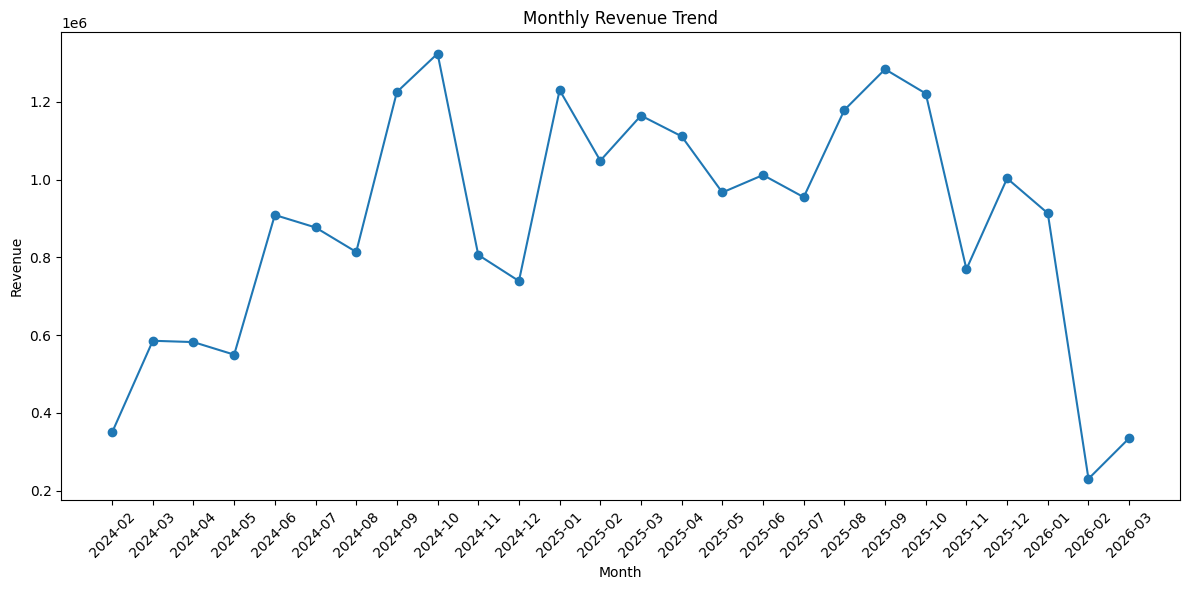

In [48]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_analysis["order_date"].astype(str),
    monthly_analysis["revenue"],
    marker ="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

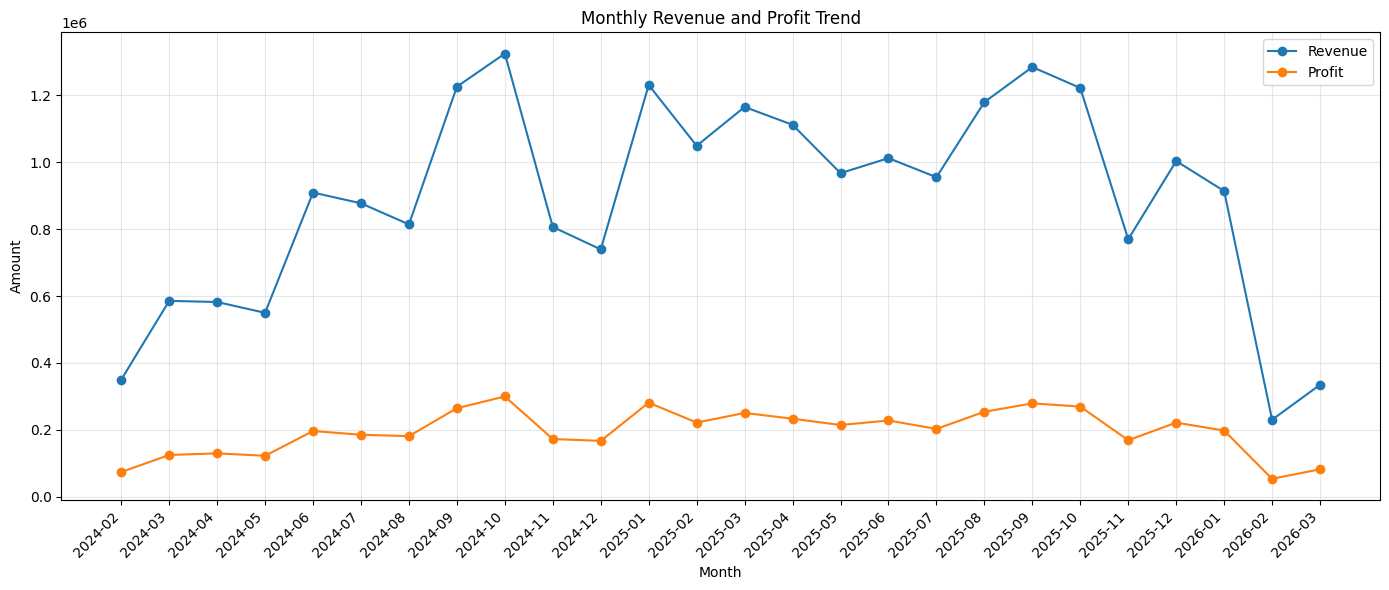

In [50]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_analysis["order_date"].astype(str),
    monthly_analysis["revenue"],
    marker="o",
    label="Revenue"
)

plt.plot(
    monthly_analysis["order_date"].astype(str),
    monthly_analysis["profit"],
    marker="o",
    label="Profit"
)

plt.title("Monthly Revenue and Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45, ha="right")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

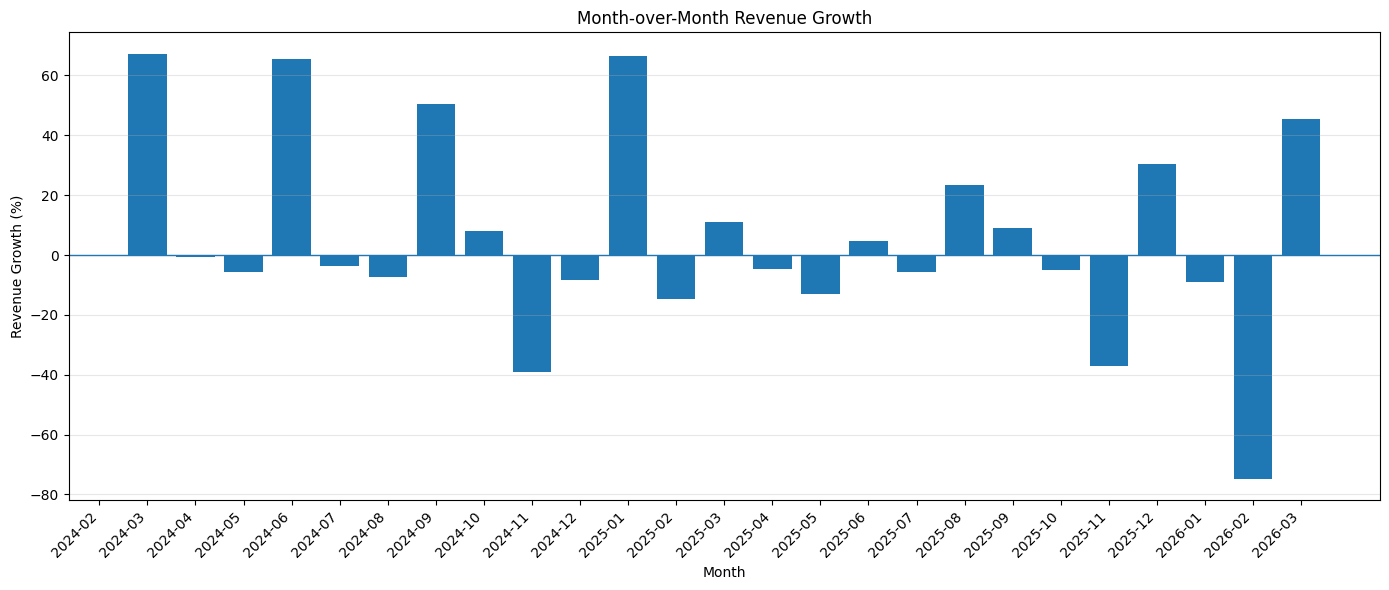

In [51]:
plt.figure(figsize=(14, 6))

plt.bar(
    monthly_analysis["order_date"].astype(str),
    monthly_analysis["revenue_growth_pct"]
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title("Month-over-Month Revenue Growth")
plt.xlabel("Month")
plt.ylabel("Revenue Growth (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [53]:
customer_analysis["revenue"].describe().round(2)

,revenue
count,498.00
mean,46558.07
std,32372.67
min,404.10
25%,22003.57
50%,35552.25
75%,66512.22
max,148876.60


In [55]:
customer_analysis["customer_segment"] = pd.qcut(
    customer_analysis["revenue"],
    q=4,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value",
        "VIP"
    ]
)

customer_analysis[
    ["customer_id", "revenue", "orders", "aov", "customer_segment"]
].head(10).round(2)

,customer_id,revenue,orders,aov,customer_segment
0,1,22790.80,2,11395.40,Medium Value
1,2,31851.50,3,10617.17,Medium Value
2,3,46558.35,3,15519.45,High Value
3,4,2496.00,3,832.00,Low Value
4,5,34782.55,3,11594.18,Medium Value
5,6,48919.50,3,16306.50,High Value
6,7,35879.05,2,17939.53,High Value
7,8,404.10,1,404.10,Low Value
8,10,11293.00,1,11293.00,Low Value
9,11,29694.60,2,14847.30,Medium Value


In [58]:
segment_analysis = (
    customer_analysis
    .groupby("customer_segment", observed=False)
    .agg(
        customers=("customer_id", "count"),
        revenue=("revenue", "sum"),
        profit=("profit", "sum"),
        orders=("orders", "sum"),
        avg_aov=("aov", "mean")
    )
    .reset_index()
)

segment_analysis["revenue_share_pct"] = (
    segment_analysis["revenue"] / segment_analysis["revenue"].sum() * 100
)

segment_analysis[
    ["revenue", "profit", "avg_aov", "revenue_share_pct"]
] = segment_analysis[
    ["revenue", "profit", "avg_aov", "revenue_share_pct"]
].round(2)

segment_analysis

,customer_segment,customers,revenue,profit,orders,avg_aov,revenue_share_pct
0,Low Value,125,1888514.5,418305.80,392,5142.28,8.15
1,Medium Value,124,3554156.1,749102.46,334,11723.42,15.33
2,High Value,124,5834822.2,1284730.92,378,17554.30,25.17
3,VIP,125,11908425.7,2630634.66,618,19422.95,51.36


## Pareto Analysis - Revenue Concentration

In [60]:
pareto = (
    customer_analysis
    .sort_values("revenue", ascending=False)
    .reset_index(drop=True)
    .copy()
)

pareto["cumulative_revenue"] = pareto["revenue"].cumsum()

pareto["cumulative_revenue_pct"] = (
    pareto["cumulative_revenue"] / pareto["revenue"].sum() * 100
)

pareto["cumulative_customers_pct"] = (
    (pareto.index + 1) / len(pareto) * 100
)

pareto[
    [
        "customer_id",
        "revenue",
        "cumulative_revenue_pct",
"cumulative_customers_pct"
    ]
].head(10).round(2)

,customer_id,revenue,cumulative_revenue_pct,cumulative_customers_pct
0,494,148876.60,0.64,0.20
1,333,145300.65,1.27,0.40
2,444,139009.95,1.87,0.60
3,264,136308.65,2.46,0.80
4,384,133815.70,3.03,1.00
5,454,131746.30,3.60,1.20
6,453,130847.40,4.17,1.41
7,324,129556.75,4.72,1.61
8,124,128880.80,5.28,1.81
9,24,128688.70,5.84,2.01


In [61]:
customers_80 = pareto[

    pareto["cumulative_revenue_pct"] >= 80
].iloc[0]

print("Customers needed for 80% of revenue:",
      int(customers_80.name + 1)
      )

print("Share of customers:",
      round(customers_80["cumulative_customers_pct"], 2),
      "%"
      )

Customers needed for 80% of revenue: 273
Share of customers: 54.82 %


## Pareto Curve - Customer Revenue Concentration

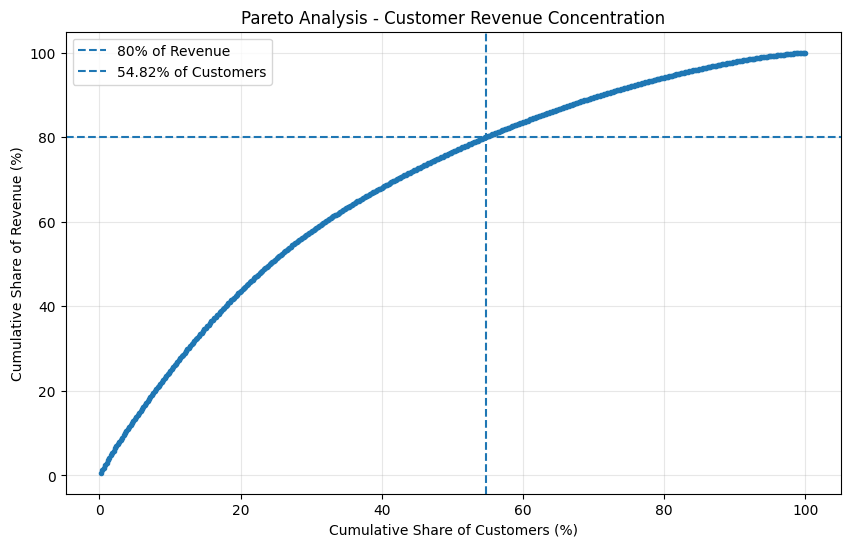

In [63]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(
    pareto["cumulative_customers_pct"],
    pareto["cumulative_revenue_pct"],
    marker="."
)

plt.axhline(
    y=80,
    linestyle="--",
    label="80% of Revenue"
)

plt.axvline(
    x=customers_80["cumulative_customers_pct"],
        linestyle="--",

    label=f'{customers_80["cumulative_customers_pct"]:.2f}% of Customers'
)

plt.xlabel("Cumulative Share of Customers (%)")
plt.ylabel("Cumulative Share of Revenue (%)")
plt.title("Pareto Analysis - Customer Revenue Concentration")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## RFM Customer Analysis
## RFM Analysis evaluates customers based on:
## - Recency - how recently the customer purchased
## - Frequency - how often the customer purchased
## - Monetary - how much revenue the customer generated

In [68]:
analysis_date = completed["order_date"].max() + pd.Timedelta(days=1)

rfm = (
    completed
    .groupby("customer_id")
    .agg(
        last_purchase=("order_date", "max"),
        frequency=("order_id", "nunique"),
        monetary=("net_amount", "sum")
    )
    .reset_index()
)

rfm["recency"] = (
    analysis_date - rfm["last_purchase"]
).dt.days

rfm[
    ["customer_id", "recency", "frequency", "monetary"]
].head(10)

,customer_id,recency,frequency,monetary
0,1,400,2,22790.80
1,2,394,3,31851.50
2,3,374,3,46558.35
3,4,356,3,2496.00
4,5,346,3,34782.55
5,6,334,3,48919.50
6,7,331,2,35879.05
7,8,336,1,404.10
8,10,289,1,11293.00
9,11,275,2,29694.60


In [69]:
rfm["R_score"] = pd.qcut(
    rfm["recency"],
    q=4,
    labels=[4, 3, 2, 1]
)

In [70]:
rfm["M_score"] = pd.qcut(
    rfm["monetary"],
    q=4,
    labels=[1, 2, 3, 4]
)

In [71]:
rfm["frequency"].value_counts().sort_index()

,count
frequency,
1,4
2,148
3,106
4,96
5,144


In [72]:
rfm[["recency", "frequency", "monetary"]].describe().round(2)

,recency,frequency,monetary
count,498.00,498.00,498.00
mean,357.42,3.46,46558.07
std,197.76,1.21,32372.67
min,1.00,1.00,404.10
25%,192.00,2.00,22003.57
50%,354.00,3.00,35552.25
75%,517.00,5.00,66512.22
max,722.00,5.00,148876.60


In [73]:
rfm["F_score"] = rfm["frequency"].map({
    1: 1,
    2: 1,
    3: 2,
    4: 3,
    5: 4
})

In [74]:
rfm[
    [
        "customer_id",
        "recency",
        "frequency",
        "monetary",
        "R_score",
        "F_score",
        "M_score"
    ]
].head(10)

,customer_id,recency,frequency,monetary,R_score,F_score,M_score
0,1,400,2,22790.80,2,1,2
1,2,394,3,31851.50,2,2,2
2,3,374,3,46558.35,2,2,3
3,4,356,3,2496.00,2,2,1
4,5,346,3,34782.55,3,2,2
5,6,334,3,48919.50,3,2,3
6,7,331,2,35879.05,3,1,3
7,8,336,1,404.10,3,1,1
8,10,289,1,11293.00,3,1,1
9,11,275,2,29694.60,3,1,2


In [75]:
rfm["RFM_score"] = (
    rfm["R_score"].astype(int) +
    rfm["F_score"].astype(int) +
    rfm["M_score"].astype(int)
)

rfm[
    [
        "customer_id",
        "recency",
        "frequency",
        "monetary",
        "R_score",
        "F_score",
        "M_score",
        "RFM_score"
    ]
].head(10)

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,1,400,2,22790.80,2,1,2,5
1,2,394,3,31851.50,2,2,2,6
2,3,374,3,46558.35,2,2,3,7
3,4,356,3,2496.00,2,2,1,5
4,5,346,3,34782.55,3,2,2,7
5,6,334,3,48919.50,3,2,3,8
6,7,331,2,35879.05,3,1,3,7
7,8,336,1,404.10,3,1,1,5
8,10,289,1,11293.00,3,1,1,5
9,11,275,2,29694.60,3,1,2,6


In [83]:
def assign_rfm_segment(row):
  r = int(row["R_score"])
  f = int(row["F_score"])
  m = int(row["M_score"])

  if r >= 3 and f >= 3 and m >= 3:
    return "Champions"
  elif r >= 3 and f >= 3:
    return "Loyal Customers"
  elif r >= 3 and f <= 2:
    return "Potential Loyalists"
  elif r <= 2 and f >= 3 and m >= 3:
    return "At Risk"
  elif r <= 2 and f <= 2:
    return "Lost Customers"
  else:
    return "Other"

rfm["RFM_segment"] = rfm.apply(assign_rfm_segment, axis=1)

rfm[
    [
        "customer_id",
        "recency",
        "frequency",
        "monetary",
        "R_score",
        "F_score",
        "M_score",
           "RFM_score",
           "RFM_segment"
    ]
  ].head(20)


,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,RFM_segment
0,1,400,2,22790.80,2,1,2,5,Lost Customers
1,2,394,3,31851.50,2,2,2,6,Lost Customers
2,3,374,3,46558.35,2,2,3,7,Lost Customers
3,4,356,3,2496.00,2,2,1,5,Lost Customers
4,5,346,3,34782.55,3,2,2,7,Potential Loyalists
5,6,334,3,48919.50,3,2,3,8,Potential Loyalists
6,7,331,2,35879.05,3,1,3,7,Potential Loyalists
7,8,336,1,404.10,3,1,1,5,Potential Loyalists
8,10,289,1,11293.00,3,1,1,5,Potential Loyalists
9,11,275,2,29694.60,3,1,2,6,Potential Loyalists


In [84]:
rfm["RFM_segment"].value_counts()

,count
RFM_segment,
Lost Customers,129
Potential Loyalists,129
Champions,91
At Risk,80
Other,40
Loyal Customers,29


In [87]:
rfm_segment_analysis = (
    rfm
    .groupby("RFM_segment")
    .agg(
        customers=("customer_id", "count"),
        revenue=("monetary", "sum"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean")
    )
    .reset_index()
)

rfm_segment_analysis[
    ["revenue", "avg_recency", "avg_frequency", "avg_monetary"]
    ] = rfm_segment_analysis[
        ["revenue", "avg_recency", "avg_frequency", "avg_monetary"]
    ].round(2)

rfm_segment_analysis


,RFM_segment,customers,revenue,avg_recency,avg_frequency,avg_monetary
0,At Risk,80,6678385.10,537.24,4.85,83479.81
1,Champions,91,7446127.25,190.82,4.82,81825.57
2,Lost Customers,129,3586770.35,518.83,2.46,27804.42
3,Loyal Customers,29,599538.90,196.90,4.00,20673.76
4,Other,40,849908.85,521.65,4.03,21247.72
5,Potential Loyalists,129,4025188.05,187.18,2.33,31203.01


In [88]:
rfm_segment_analysis["revenue_share_pct"] = (
    rfm_segment_analysis["revenue"] / rfm_segment_analysis["revenue"].sum() * 100
).round(2)

rfm_segment_analysis

,RFM_segment,customers,revenue,avg_recency,avg_frequency,avg_monetary,revenue_share_pct
0,At Risk,80,6678385.10,537.24,4.85,83479.81,28.80
1,Champions,91,7446127.25,190.82,4.82,81825.57,32.11
2,Lost Customers,129,3586770.35,518.83,2.46,27804.42,15.47
3,Loyal Customers,29,599538.90,196.90,4.00,20673.76,2.59
4,Other,40,849908.85,521.65,4.03,21247.72,3.67
5,Potential Loyalists,129,4025188.05,187.18,2.33,31203.01,17.36


In [89]:
at_risk_top = (
    rfm[rfm["RFM_segment"] == "At Risk"]
    .sort_values("monetary", ascending=False)
    [
      [
        "customer_id",
        "recency",
        "frequency",
        "monetary",
        "R_score",
        "F_score",
        "M_score"
    ]
  ]
    .head(10)
)

at_risk_top

,customer_id,recency,frequency,monetary,R_score,F_score,M_score
330,333,479,5,145300.65,2,4,4
441,444,391,5,139009.95,2,4,4
321,324,526,5,129556.75,1,4,4
121,124,526,5,128880.80,1,4,4
21,24,526,5,128688.70,1,4,4
41,44,391,5,119389.15,2,4,4
201,204,686,5,118381.15,1,4,4
221,224,526,5,115631.80,1,4,4
131,134,471,5,113509.90,2,4,4
341,344,391,5,109693.30,2,4,4


In [91]:
rfm_segment_analysis["customer_share_pct"] = (
    rfm_segment_analysis["customers"] / rfm_segment_analysis["customers"].sum() * 100
).round(2)

rfm_segment_analysis[
    [
        "RFM_segment",
        "customers",
        "customer_share_pct",
        "revenue",
        "revenue_share_pct",
        "avg_recency",
        "avg_frequency",
        "avg_monetary"
    ]
]

,RFM_segment,customers,customer_share_pct,revenue,revenue_share_pct,avg_recency,avg_frequency,avg_monetary
0,At Risk,80,16.06,6678385.10,28.80,537.24,4.85,83479.81
1,Champions,91,18.27,7446127.25,32.11,190.82,4.82,81825.57
2,Lost Customers,129,25.90,3586770.35,15.47,518.83,2.46,27804.42
3,Loyal Customers,29,5.82,599538.90,2.59,196.90,4.00,20673.76
4,Other,40,8.03,849908.85,3.67,521.65,4.03,21247.72
5,Potential Loyalists,129,25.90,4025188.05,17.36,187.18,2.33,31203.01


In [92]:
customer_orders = (
    completed
    [["customer_id", "order_id", "order_date"]]
    .drop_duplicates()
    .sort_values(["customer_id", "order_date"])
)

customer_orders["days_between_orders"] = (
    customer_orders
    .groupby("customer_id")
    ["order_date"]
    .diff()
    .dt.days
)

In [94]:
customer_orders["days_between_orders"].describe().round(2)

,days_between_orders
count,1224.00
mean,22.24
std,11.70
min,14.00
25%,20.00
50%,20.00
75%,20.00
max,80.00


In [95]:
discount_analysis = (
    completed
    .groupby("discount_percent")
    .agg(
        orders=("order_id", "nunique"),
        units=("quantity", "sum"),
        revenue=("net_amount", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

discount_analysis

,discount_percent,orders,units,revenue,profit
0,0.0,1549,6947,16372397.0,4061198.50
1,5.0,394,846,1996140.0,414960.66
2,10.0,613,1457,3069755.1,499516.48
3,20.0,427,976,1747626.4,107098.20


In [96]:
discount_analysis["profit_margin_pct"] = (
    discount_analysis["profit"]
    /
    discount_analysis["revenue"] * 100
).round(2)

discount_analysis[
    [
        "discount_percent",
        "orders",
        "units",
        "revenue",
        "profit",
        "profit_margin_pct"
    ]
]

,discount_percent,orders,units,revenue,profit,profit_margin_pct
0,0.0,1549,6947,16372397.0,4061198.50,24.81
1,5.0,394,846,1996140.0,414960.66,20.79
2,10.0,613,1457,3069755.1,499516.48,16.27
3,20.0,427,976,1747626.4,107098.20,6.13


In [97]:
category_margin = (
    completed
    .groupby("category_name")
    .agg(
        revenue=("net_amount", "sum"),
        profit=("profit", "sum"),
        units=("quantity", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

category_margin["profit_margin_pct"] = (
    category_margin["profit"] / category_margin["revenue"] * 100
).round(2)

category_margin[
    [
        "category_name",
        "orders",
        "units",
        "revenue",
        "profit",
        "profit_margin_pct"
    ]
].sort_values("profit_margin_pct", ascending=False)

,category_name,orders,units,revenue,profit,profit_margin_pct
5,Smart Home,596,1372,2763792.05,683571.73,24.73
0,Accessories,553,1272,2499944.85,581966.55,23.28
4,Monitors,592,1398,3335417.85,760635.29,22.80
7,Tablets,513,1175,2751551.85,598414.37,21.75
1,Audio,538,1281,2580157.10,552307.30,21.41
6,Smartphones,525,1239,3133924.25,662584.61,21.14
3,Laptops,530,1223,3243095.55,663757.27,20.47
2,Gaming,539,1266,2878035.00,579536.72,20.14


##Final Business Insights and Recommendations

### Key Insights

1. Monthly revenue is strongly associated with order volume.
   Monthly revenue showed a very strong positive correlation with order volume, while the relationship with AOV was much weaker.

2. Customer value is highly concentrated. Champions and At   Risk customers together represent only 34.33% of the   customer base while accounting for 60.91% of historical revenue. This highlights both the importance of retaining Champions and the financial risk associated with losing At Risk customers.

3. At Risk customers require immediate attention.
   They account for only 16.06% of customers but generate 28.80% of revenue.
   Their average frequency is 4.85 orders and average monetary value is 83,479.81, but average recency is 537 days.

4. Potential Loyalists represent a major growth opportunity.
   They account for 25.90% of customers but generate only 17.36% of revenue, suggesting significant potential for repeat-purchase campaigns.

5. The typical interval between repeat purchases is  approximately 20 days. The median is 20 days and the mean is 22.24 days, suggesting that retention campaigns could be initiated around 2–3 weeks after a purchase.

6. Higher discounts significantly reduce profitability.
   Profit margin decreases from 24.81% with no discount to:
   - 20.79% at 5%
   - 16.27% at 10%
   - 6.13% at 20%

7. Smart Home has the highest category profit margin at 24.73%.
   However, Monitors generate the highest absolute revenue and profit, with revenue of 3.34M and profit of 760.6K.

### Business Recommendations

- Prioritize reactivation campaigns for high-value At Risk customers.
- Target Potential Loyalists with loyalty programs and repeat-purchase incentives.
- Schedule retention communication approximately 2–3 weeks after a purchase.
- Use high discounts selectively because 20% discounts significantly reduce profit margin.
- Maintain focus on Monitors because of their strong absolute revenue and profit performance.
- Use Smart Home products as a high-margin category for profitable growth.